# Experiment 01: Simple CNN Baseline

In this notebook, I build the first baseline model for the Facial Expression Recognition Challenge.

The goal of this experiment is to download the Kaggle dataset, preprocess 48x48 grayscale face images, train a simple CNN baseline, and log all results to Weights & Biases.

## 1. Installing Required Libraries

In this step, I install the libraries needed for the experiment.

- `kaggle` is used to download the competition dataset directly from Kaggle.
- `wandb` is used to track experiments, metrics, and hyperparameters.

In [1]:
!pip install kaggle wandb -Uq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.0/231.0 kB 5.3 MB/s eta 0:00:00


## 2. Mounting Google Drive

I mount Google Drive so that Colab can access files stored in my Drive. In this project, the Kaggle API credentials file `kaggle.json` is stored in Google Drive and copied into the correct Kaggle configuration folder.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 3. Setting Up Kaggle API Credentials

The Kaggle API requires a credentials file named `kaggle.json`. I store this file in Google Drive and copy it into the `~/.kaggle/` directory, where the Kaggle command line tool expects it.

The permission is changed to `600` to make the file readable only by the current user. This is required by the Kaggle API for security reasons.

In [3]:
!mkdir -p ~/.kaggle
!cp /content/drive/MyDrive/ML_Assignment4/kaggle.json ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

## 4. Verifying Kaggle Credentials

This cell checks whether the `kaggle.json` file was successfully copied into the Kaggle configuration directory. If the file appears in the output, the Kaggle API should be ready to use.

In [4]:
!ls -la ~/.kaggle

total 16
drwxr-xr-x 2 root root 4096 Jun 17 09:41 .
drwx------ 1 root root 4096 Jun 17 09:41 ..
-rw------- 1 root root   63 Jun 17 09:41 kaggle.json


## 5. Downloading the Kaggle Dataset

I download the Facial Expression Recognition Challenge dataset directly from Kaggle using the Kaggle API. This makes the notebook reproducible, because the dataset can be downloaded again without manually uploading the CSV files.

In [5]:
!kaggle competitions download -c challenges-in-representation-learning-facial-expression-recognition-challenge

100% 285M/285M [00:01<00:00, 176MB/s]



## 6. Extracting the Dataset

The downloaded Kaggle dataset is provided as a zip file. I extract it into a separate `data/` folder to keep the notebook directory organized. After extraction, I list the files to confirm that the CSV files are available.

In [6]:
!mkdir -p data
!unzip -q challenges-in-representation-learning-facial-expression-recognition-challenge.zip -d data
!ls data

example_submission.csv	fer2013.tar.gz	icml_face_data.csv  test.csv  train.csv


### 7. Load and Inspecting the Dataset

This cell checks the shape and columns of the dataset. This is important because it confirms how the data is stored before preprocessing.

The important columns are:
- `emotion`: the target label
- `pixels`: a string containing 2304 pixel values for a 48x48 grayscale image\

In [7]:
import pandas as pd

df = pd.read_csv("data/train.csv")

print(df.shape)
print(df.columns)
df.head()

(28709, 2)
Index(['emotion', 'pixels'], dtype='object')


,emotion,pixels
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...
1,0,151 150 147 155 148 133 111 140 170 174 182 15...
2,2,231 212 156 164 174 138 161 173 182 200 106 38...
3,4,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...
4,6,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...


## 8. Logging Into Weights & Biases

I use Weights & Biases to track the experiment. This allows me to save hyperparameters, training loss, validation loss, training accuracy, and validation accuracy for each model run.

In [9]:
import wandb
wandb.login()

True

## 9. Importing Libraries and Selecting Device

In this cell, I import the libraries needed for numerical processing, visualization, data splitting, and PyTorch training.

I also select the training device. If a GPU is available, the model will train on CUDA. Otherwise, it will train on CPU.

In [10]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device available:", device)

Device available: cpu


## 10. Mapping Emotion Labels to Class Names

The dataset stores emotion labels as integers from 0 to 6. I map these integers to human-readable emotion names so that plots and analysis are easier to understand.

The seven classes are Angry, Disgust, Fear, Happy, Sad, Surprise, and Neutral.

In [11]:
emotion_map = {
    0: "Angry",
    1: "Disgust",
    2: "Fear",
    3: "Happy",
    4: "Sad",
    5: "Surprise",
    6: "Neutral"
}

df["emotion_name"] = df["emotion"].map(emotion_map)
df.head()

,emotion,pixels,emotion_name
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...,Angry
1,0,151 150 147 155 148 133 111 140 170 174 182 15...,Angry
2,2,231 212 156 164 174 138 161 173 182 200 106 38...,Fear
3,4,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...,Sad
4,6,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...,Neutral


## 11. Class Distribution

I visualize the distribution of emotion classes in the dataset. This helps identify class imbalance. For example, some emotions may have fewer samples than others, which can make them harder for the model to learn.

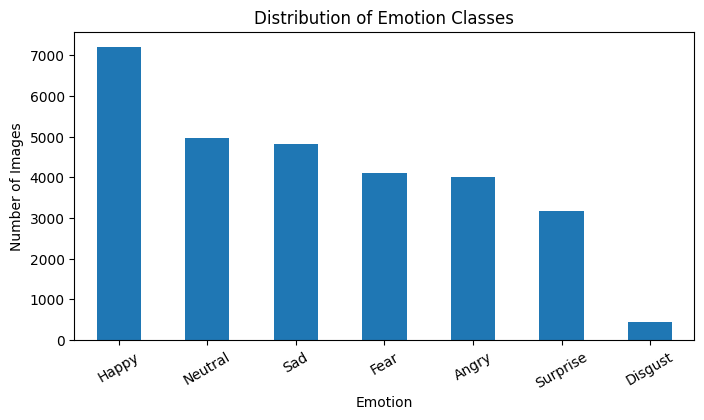

In [11]:
plt.figure(figsize=(8, 4))
df["emotion_name"].value_counts().plot(kind="bar")
plt.title("Distribution of Emotion Classes")
plt.xlabel("Emotion")
plt.ylabel("Number of Images")
plt.xticks(rotation=30)
plt.show()

## 12. Visualizing Example Images

Each image is stored as a string of 2304 pixel values. I convert this string into a 48x48 grayscale image and visualize one example from each emotion class.

This step helps confirm that the pixel conversion works correctly and that the images match the expected facial expression labels.

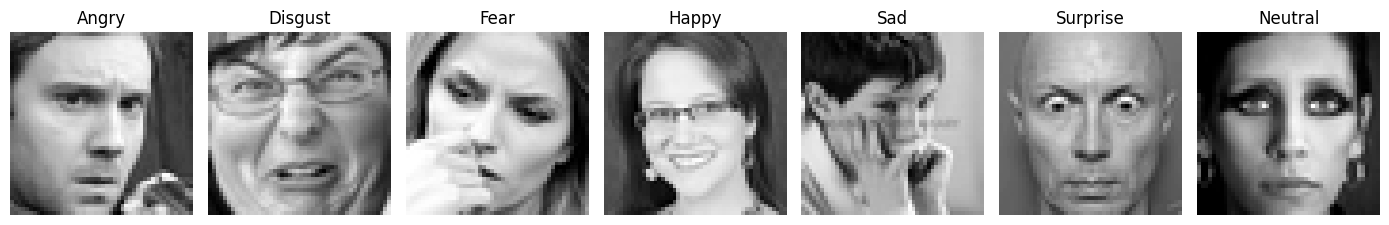

In [12]:
def pixels_to_image(pixels_str):
    pixels = np.array(pixels_str.split(), dtype=np.uint8)
    image = pixels.reshape(48, 48)
    return image

plt.figure(figsize=(14, 4))

for i, emotion_id in enumerate(sorted(df["emotion"].unique())):
    row = df[df["emotion"] == emotion_id].iloc[0]
    image = pixels_to_image(row["pixels"])

    plt.subplot(1, 7, i + 1)
    plt.imshow(image, cmap="gray")
    plt.title(emotion_map[emotion_id])
    plt.axis("off")

plt.tight_layout()
plt.show()

## 13. Converting Pixel Strings to Image Arrays

The original `pixels` column stores images as strings. I convert each pixel string into a NumPy array with shape `(48, 48)`. This format is easier to preprocess and convert into PyTorch tensors.

In [13]:
df["pixels_array"] = df["pixels"].apply(pixels_to_image)

print(type(df["pixels_array"].iloc[0]))
print(df["pixels_array"].iloc[0].shape)

<class 'numpy.ndarray'>
(48, 48)


## 14. Train, Validation, and Internal Test Split

The Kaggle test set does not contain labels, so I split the provided training data into three parts:

- training set for updating model parameters
- validation set for model selection during training
- internal test set for final evaluation of this baseline

I use stratified splitting so that the class distribution remains similar across all splits.

In [14]:
X = df["pixels_array"]
y = df["emotion"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test_new, y_val, y_test_new = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train size:", len(X_train))
print("Validation size:", len(X_val))
print("New test size:", len(X_test_new))

Train size: 20096
Validation size: 4306
New test size: 4307


## 15. Converting Images and Labels to PyTorch Tensors

Before training, the image arrays must be converted into PyTorch tensors.

I normalize pixel values from `[0, 255]` to `[0, 1]`. I also add a channel dimension, because PyTorch convolutional layers expect image tensors in the format `[batch_size, channels, height, width]`.

For grayscale FER2013 images, the final input shape is `[N, 1, 48, 48]`.

In [15]:
def convert_to_tensors(images, labels):
    image_array = np.stack(images.values).astype(np.float32)
    image_array = image_array / 255.0

    # shape: [N, 48, 48] -> [N, 1, 48, 48]
    image_tensor = torch.tensor(image_array, dtype=torch.float32).unsqueeze(1)
    label_tensor = torch.tensor(labels.values, dtype=torch.long)

    return image_tensor, label_tensor

X_train_tensor, y_train_tensor = convert_to_tensors(X_train, y_train)
X_val_tensor, y_val_tensor = convert_to_tensors(X_val, y_val)
X_test_tensor, y_test_tensor = convert_to_tensors(X_test_new, y_test_new)

print("Train images:", X_train_tensor.shape)
print("Train labels:", y_train_tensor.shape)
print("Validation images:", X_val_tensor.shape)
print("Test images:", X_test_tensor.shape)

Train images: torch.Size([20096, 1, 48, 48])
Train labels: torch.Size([20096])
Validation images: torch.Size([4306, 1, 48, 48])
Test images: torch.Size([4307, 1, 48, 48])


## 16. Creating a PyTorch Dataset

I define a custom PyTorch Dataset class. This class stores image tensors and label tensors and returns one `(image, label)` pair at a time.

This makes the data compatible with PyTorch DataLoader.

In [16]:
class EmotionDataset(Dataset):
    def __init__(self, images, labels):
        self.images = images
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]
        return image, label

## 17. Creating DataLoaders

I create DataLoader objects for the training, validation, and internal test sets.

The training DataLoader uses shuffling so that the model sees the data in a different order each epoch. Validation and test DataLoaders do not use shuffling because they are only used for evaluation.

In [17]:
batch_size = 64

train_dataset = EmotionDataset(X_train_tensor, y_train_tensor)
val_dataset = EmotionDataset(X_val_tensor, y_val_tensor)
test_dataset = EmotionDataset(X_test_tensor, y_test_tensor)

train_dataloader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_dataloader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_dataloader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Number of train batches:", len(train_dataloader))
print("Number of validation batches:", len(val_dataloader))
print("Number of test batches:", len(test_dataloader))

Number of train batches: 314
Number of validation batches: 68
Number of test batches: 68


## 18. Data Sanity Check

Before training the model, I inspect one batch from the training DataLoader.

This check confirms that:
- images have shape `[batch_size, 1, 48, 48]`
- labels have shape `[batch_size]`
- image values are normalized to `[0, 1]`
- labels are integer class IDs

This helps verify that the preprocessing and DataLoader pipeline are correct.

In [18]:
first_batch_images, first_batch_labels = next(iter(train_dataloader))

print("Image batch shape:", first_batch_images.shape)
print("Label batch shape:", first_batch_labels.shape)
print("Image dtype:", first_batch_images.dtype)
print("Label dtype:", first_batch_labels.dtype)
print("Min pixel:", first_batch_images.min().item())
print("Max pixel:", first_batch_images.max().item())
print("First 10 labels:", first_batch_labels[:10])

Image batch shape: torch.Size([64, 1, 48, 48])
Label batch shape: torch.Size([64])
Image dtype: torch.float32
Label dtype: torch.int64
Min pixel: 0.0
Max pixel: 1.0
First 10 labels: tensor([0, 3, 3, 5, 3, 4, 4, 3, 6, 3])


## 19. Defining the WandB Project and Initializing the First WandB Run
I define the WandB project name. All runs for this assignment will be logged under the same project, while each architecture will have a separate run.

**This** cell creates the first WandB run for the Simple CNN baseline. I log the main hyperparameters and model settings in the run configuration.

This experiment does not use Batch Normalization, Dropout, or data augmentation. It is intentionally simple so that it can serve as the baseline for later experiments.

In [19]:
WANDB_PROJECT = "Facial_Expression_Recognition"
run = wandb.init(
    project=WANDB_PROJECT,
    name="exp01_simple_cnn_baseline_lr_0_0007_epochs_15",
    config={
        "learning_rate": 0.0007,
        "epochs": 15,
        "batch_size": 64,
        "optimizer": "Adam",
        "loss_function": "CrossEntropyLoss",
        "architecture": "SimpleCNN",

        "conv1_out_channels": 16,
        "conv2_out_channels": 32,
        "fc_hidden_dim": 128,
        "kernel_size": 3,
        "padding": 1,
        "pooling": "MaxPool2d(kernel_size=2, stride=2)",

        "batch_norm": False,
        "dropout": False,
        "augmentation": False
    }
)

## 20. Simple CNN Baseline Architecture

I define the first baseline model: a simple convolutional neural network.

The model contains two convolutional layers followed by max pooling. These layers learn local visual features from the face images. After the convolutional blocks, the feature maps are flattened and passed through fully connected layers to produce logits for the seven emotion classes.

This model is intentionally simple. It does not use Batch Normalization, Dropout, or data augmentation, so it serves as a baseline for later experiments.

In [19]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=7):
        super(SimpleCNN, self).__init__()

        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=16,
            kernel_size=3,
            padding=1
        )

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(
            in_channels=16,
            out_channels=32,
            kernel_size=3,
            padding=1
        )

        self.fc1 = nn.Linear(32 * 12 * 12, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # [B, 16, 24, 24]
        x = self.pool(F.relu(self.conv2(x)))   # [B, 32, 12, 12]
        x = x.view(x.size(0), -1)              # [B, 32*12*12]
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

## 21. Forward Pass Check

1.   List item
2.   List item



I run one batch through the model to verify that the forward pass works correctly.

The expected output shape is `[batch_size, 7]`, because the model should produce one logit for each of the seven emotion classes.

In [21]:
model = SimpleCNN(num_classes=7).to(device)

images, labels = next(iter(train_dataloader))
images = images.to(device)

outputs = model(images)

print("Output shape:", outputs.shape)

Output shape: torch.Size([64, 7])


## 22. Backward Pass and Gradient Check

I compute the loss for one batch and run backpropagation using `loss.backward()`.

This verifies that gradients are successfully computed for the model parameters. If gradients exist and their values are non-zero, the model can be trained using gradient descent.

In [22]:
criterion = nn.CrossEntropyLoss()

images, labels = next(iter(train_dataloader))
images = images.to(device)
labels = labels.to(device)

model = SimpleCNN(num_classes=7).to(device)

outputs = model(images)
loss = criterion(outputs, labels)

print("Loss:", loss.item())

loss.backward()

first_param = next(model.parameters())
print("Gradient exists:", first_param.grad is not None)
print("Gradient mean:", first_param.grad.abs().mean().item())

Loss: 1.9354115724563599
Gradient exists: True
Gradient mean: 0.0006482828757725656


## 23. Watching the Model with WandB

I use `wandb.watch()` to track the model during training. This can log information about gradients and parameters, which is useful for debugging training behavior.

In [23]:
model = SimpleCNN(num_classes=7).to(device)
wandb.watch(model, log="all")

## 24. Training Function

This function trains the model for one epoch.

For each batch, it:
1. moves images and labels to the selected device,
2. performs a forward pass,
3. computes the cross-entropy loss,
4. clears old gradients,
5. performs backpropagation,
6. updates model parameters using the optimizer,
7. calculates training accuracy.

The function returns the average training loss and training accuracy for the epoch.

In [24]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for inputs, labels in dataloader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

        predictions = outputs.argmax(dim=1)
        correct_predictions += (predictions == labels).sum().item()
        total_samples += labels.size(0)

    epoch_loss = running_loss / total_samples
    epoch_accuracy = correct_predictions / total_samples

    return epoch_loss, epoch_accuracy

## 25. Evaluation Function

This function evaluates the model on validation or test data.

The model is switched to evaluation mode using `model.eval()`, and gradients are disabled using `torch.no_grad()`. This makes evaluation faster and prevents the model from updating its parameters.

The function returns average loss and accuracy.

In [25]:
def validate_epoch(model, dataloader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)

            predictions = outputs.argmax(dim=1)
            correct_predictions += (predictions == labels).sum().item()
            total_samples += labels.size(0)

    epoch_loss = running_loss / total_samples
    epoch_accuracy = correct_predictions / total_samples

    return epoch_loss, epoch_accuracy

## 26. Training the Simple CNN Baseline

I train the Simple CNN model using the Adam optimizer and CrossEntropyLoss.

After each epoch, I log the following metrics to WandB:
- training loss
- training accuracy
- validation loss
- validation accuracy

I also save the model checkpoint whenever validation accuracy improves. This ensures that the best version of the model is saved during training.

In [26]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0007)

num_epochs = 15
best_val_accuracy = 0.0

!mkdir -p /content/drive/MyDrive/ML_Assignment4/models
best_model_path = "/content/drive/MyDrive/ML_Assignment4/models/exp01_simple_cnn_baseline_lr_0.0007_epochs_15_sizes.pt"

for epoch in range(num_epochs):
    train_loss, train_accuracy = train_epoch(
        model,
        train_dataloader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_accuracy = validate_epoch(
        model,
        val_dataloader,
        criterion,
        device
    )

    wandb.log({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_accuracy": train_accuracy,
        "val_loss": val_loss,
        "val_accuracy": val_accuracy
    })

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.4f}"
    )

    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        torch.save(model.state_dict(), best_model_path)

print("Best validation accuracy:", best_val_accuracy)

wandb.log({"best_val_accuracy": best_val_accuracy})
wandb.save(best_model_path)

Epoch 1/15 | Train Loss: 1.7105, Train Acc: 0.3123 | Val Loss: 1.6250, Val Acc: 0.3658
Epoch 2/15 | Train Loss: 1.5516, Train Acc: 0.4045 | Val Loss: 1.5192, Val Acc: 0.4080
Epoch 3/15 | Train Loss: 1.4581, Train Acc: 0.4407 | Val Loss: 1.4491, Val Acc: 0.4350
Epoch 4/15 | Train Loss: 1.3819, Train Acc: 0.4719 | Val Loss: 1.4220, Val Acc: 0.4431
Epoch 5/15 | Train Loss: 1.3209, Train Acc: 0.4962 | Val Loss: 1.3907, Val Acc: 0.4647
Epoch 6/15 | Train Loss: 1.2711, Train Acc: 0.5140 | Val Loss: 1.3718, Val Acc: 0.4768
Epoch 7/15 | Train Loss: 1.2189, Train Acc: 0.5400 | Val Loss: 1.3712, Val Acc: 0.4705
Epoch 8/15 | Train Loss: 1.1698, Train Acc: 0.5630 | Val Loss: 1.3568, Val Acc: 0.4719
Epoch 9/15 | Train Loss: 1.1215, Train Acc: 0.5802 | Val Loss: 1.3565, Val Acc: 0.4868
Epoch 10/15 | Train Loss: 1.0711, Train Acc: 0.6014 | Val Loss: 1.3711, Val Acc: 0.4882
Epoch 11/15 | Train Loss: 1.0115, Train Acc: 0.6295 | Val Loss: 1.3884, Val Acc: 0.4803
Epoch 12/15 | Train Loss: 0.9540, Train A

wandb: WARNING Saving files without folders. If you want to preserve subdirectories pass base_path to wandb.save, i.e. wandb.save("/mnt/folder/file.h5", base_path="/mnt")
wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


Epoch 15/15 | Train Loss: 0.7786, Train Acc: 0.7195 | Val Loss: 1.4711, Val Acc: 0.4898
Best validation accuracy: 0.5004644681839294


['/content/wandb/run-20260616_210546-ktgea0fq/files/models/exp01_simple_cnn_baseline_lr_0.0007_epochs_15_sizes.pt']

## 27. Before testing, I load the best checkpoint saved according to validation accuracy.


In [27]:
# model.load_state_dict(torch.load(best_model_path, map_location=device))

## 28. Evaluating on the Internal Test Set

After training, I evaluate the model on the internal test set that was created from the original training data.

This is not the official Kaggle test set. It is used only to estimate how well the model generalizes to unseen labeled examples.



In [28]:
# test_loss, test_accuracy = validate_epoch(
#     model,
#     test_dataloader,
#     criterion,
#     device
# )

# print("New test loss:", test_loss)
# print("New test accuracy:", test_accuracy)

# wandb.log({
#     "new_test_loss": test_loss,
#     "new_test_accuracy": test_accuracy
# })

## 29. Finishing the WandB Run

At the end of the experiment, I finish the WandB run. This finalizes the logging process and makes sure all metrics and saved files are uploaded properly.

In [29]:
wandb.finish()

best_val_accuracy,▁
epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
train_accuracy,▁▃▃▄▄▄▅▅▆▆▆▇▇██
train_loss,█▇▆▆▅▅▄▄▄▃▃▂▂▁▁
val_accuracy,▁▃▅▅▆▇▆▇▇▇▇▇██▇
val_loss,█▅▃▃▂▁▁▁▁▁▂▂▃▃▄
best_val_accuracy,0.50046
epoch,15
train_accuracy,0.71955
train_loss,0.77864
val_accuracy,0.48978


## Experiment 01 Analysis

In this notebook, I trained a Simple CNN baseline for the FER2013 facial expression recognition task.

The model has two convolutional layers followed by max pooling and two fully connected layers. This architecture is intentionally simple and is used as the first baseline experiment.

Before training, I checked the full pipeline by:
- visualizing sample images,
- plotting the class distribution,
- verifying tensor shapes,
- running a forward pass,
- computing loss,
- checking that gradients are computed during the backward pass.

The model does not use Batch Normalization, Dropout, data augmentation, class weighting, or weighted sampling. Because of this, it is expected to be a reasonable starting point, but later experiments should improve generalization by adding regularization and stronger architectures.

The results show that the Simple CNN is able to learn useful patterns from the data, because training loss decreases and validation accuracy improves during training.

Best validation accuracy: TODO  
Internal test accuracy: TODO

## Evaluation Protocol

At first, I checked the internal test split too early during experimentation. I corrected this by using only validation accuracy for hyperparameter tuning and model selection. The internal test set is reserved for the final evaluation after the best validation checkpoint is selected.

## Final Test Evaluation from Saved Checkpoint

This section loads the saved SimpleCNN checkpoint from Google Drive, runs forward and backward sanity checks on the loaded model, evaluates it on the internal test split, and logs the final test results to WandB.


In [20]:
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd
import numpy as np
import torch

def evaluate_model_detailed(model, dataloader, criterion, device, emotion_map):
    model.eval()

    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)

            predictions = outputs.argmax(dim=1)

            correct_predictions += (predictions == labels).sum().item()
            total_samples += labels.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predictions.cpu().numpy())

    test_loss = running_loss / total_samples
    test_accuracy = correct_predictions / total_samples

    class_names = [emotion_map[i] for i in range(7)]

    cm = confusion_matrix(all_labels, all_predictions)

    report = classification_report(
        all_labels,
        all_predictions,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )

    report_df = pd.DataFrame(report).transpose()

    print("Test loss:", test_loss)
    print("Test accuracy:", test_accuracy)
    print("\nClassification report:")
    print(report_df)

    return test_loss, test_accuracy, cm, report_df, all_labels, all_predictions


### Experiment 01 checkpoint test

This cell loads the saved Experiment 01 model, runs forward/backward sanity checks, evaluates the internal test set, and logs everything to WandB.


In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Evaluation device:", device)

checkpoint_path = "/content/drive/MyDrive/ML_Assignment4/models/exp01_simple_cnn_baseline_lr_0.0007_epochs_15_sizes.pt"

test_model = SimpleCNN(num_classes=7).to(device)

test_model.load_state_dict(
    torch.load(checkpoint_path, map_location=device)
)

test_model.eval()

test_criterion = nn.CrossEntropyLoss()

if wandb.run is not None:
    wandb.finish()

test_run = wandb.init(
    project="Facial_Expression_Recognition",
    name="exp01_simple_cnn_test_evaluation",
    config={
        "architecture": "SimpleCNN",
        "checkpoint_path": checkpoint_path,
        "evaluation_split": "internal_test",
        "loaded_from_checkpoint": True,
        "logs_forward_backward_checks": True
    }
)

# Forward sanity check on the loaded checkpoint
test_model.eval()

sanity_inputs, sanity_labels = next(iter(train_dataloader))
sanity_inputs = sanity_inputs.to(device)
sanity_labels = sanity_labels.to(device)

with torch.no_grad():
    sanity_outputs = test_model(sanity_inputs)

print("Sanity input shape:", sanity_inputs.shape)
print("Sanity output shape:", sanity_outputs.shape)
print("Sanity labels shape:", sanity_labels.shape)

assert sanity_outputs.shape[0] == sanity_inputs.shape[0], "Batch size mismatch"
assert sanity_outputs.shape[1] == 7, "Model output should have 7 logits"
assert sanity_labels.ndim == 1, "Labels should be a 1D tensor"
assert torch.isfinite(sanity_outputs).all(), "Outputs contain NaN or Inf"

print("Forward pass check passed.")

# Backward sanity check on the loaded checkpoint
test_model.train()
test_model.zero_grad()

sanity_outputs = test_model(sanity_inputs)
sanity_loss = test_criterion(sanity_outputs, sanity_labels)

print("Sanity loss:", sanity_loss.item())

sanity_loss.backward()

total_grad_norm = 0.0
num_params_with_grad = 0

for name, param in test_model.named_parameters():
    if param.requires_grad and param.grad is not None:
        grad_norm = param.grad.data.norm(2).item()
        total_grad_norm += grad_norm
        num_params_with_grad += 1

print("Number of parameters with gradients:", num_params_with_grad)
print("Total gradient norm:", total_grad_norm)

assert torch.isfinite(sanity_loss), "Loss is NaN or Inf"
assert num_params_with_grad > 0, "No gradients were computed"
assert total_grad_norm > 0, "Gradient norm is zero"

test_model.zero_grad()
test_model.eval()

wandb.log({
    "forward_check_passed": 1,
    "backward_check_passed": 1,
    "sanity_initial_loss": sanity_loss.item(),
    "sanity_num_params_with_grad": num_params_with_grad,
    "sanity_total_grad_norm": total_grad_norm
})

print("Backward pass check passed.")

# Final internal test evaluation
test_loss, test_accuracy, cm, report_df, all_labels, all_predictions = evaluate_model_detailed(
    test_model,
    test_dataloader,
    test_criterion,
    device,
    emotion_map
)

class_names = [emotion_map[i] for i in range(7)]

wandb.log({
    "test_loss": test_loss,
    "test_accuracy": test_accuracy
})

wandb.log({
    "confusion_matrix": wandb.plot.confusion_matrix(
        y_true=all_labels,
        preds=all_predictions,
        class_names=class_names
    )
})

wandb.log({
    "classification_report": wandb.Table(dataframe=report_df.reset_index())
})

wandb.finish()
print("Experiment 01 final test evaluation finished.")


Evaluation device: cpu


Sanity input shape: torch.Size([64, 1, 48, 48])
Sanity output shape: torch.Size([64, 7])
Sanity labels shape: torch.Size([64])
Forward pass check passed.
Sanity loss: 0.5938675403594971
Number of parameters with gradients: 8
Total gradient norm: 8.22755216807127
Backward pass check passed.
Test loss: 1.3709375674524744
Test accuracy: 0.513118179707453

Classification report:
              precision    recall  f1-score      support
Angry          0.415254  0.409015  0.412111   599.000000
Disgust        0.534884  0.353846  0.425926    65.000000
Fear           0.410148  0.315447  0.356618   615.000000
Happy          0.633617  0.755309  0.689132  1083.000000
Sad            0.383915  0.348966  0.365607   725.000000
Surprise       0.649351  0.631579  0.640342   475.000000
Neutral        0.477820  0.506040  0.491525   745.000000
accuracy       0.513118  0.513118  0.513118     0.513118
macro avg      0.500713  0.474315  0.483037  4307.000000
weighted avg   0.502603  0.513118  0.505132  4307.00

backward_check_passed,▁
forward_check_passed,▁
sanity_initial_loss,▁
sanity_num_params_with_grad,▁
sanity_total_grad_norm,▁
test_accuracy,▁
test_loss,▁
backward_check_passed,1
forward_check_passed,1
sanity_initial_loss,0.59387
sanity_num_params_with_grad,8


Experiment 01 final test evaluation finished.
